# Balanced pool

`balanced_pool()` returns 42 pre-configured generators spanning 15 behavioral niches — ARMA and exponential smoothing, long-range memory and volatility clustering, intermittent demand, deterministic chaos, counts, bounded and heavy-tailed processes, and more. It is the default corpus behind [`generate_series`](../getting-started/quickstart), and a bias-free starting point for benchmarking or pretraining: generators are allocated proportionally to each niche's behavioral range, so no single domain (finance, say) dominates the pool.

::: {.callout-note}
## What's in, and what's deliberately out

The pool draws from *interpretable, single-mechanism* generators — each slot is one named data-generating process. The meta-generators (`TSIGenerator`, `TCMGenerator`, `KernelSynthGenerator`) are excluded on purpose: they already randomize across many behaviors internally, so folding them in would blur the one-niche-one-mechanism design. Reach for the [`pretraining_pool()`](../generators/pretraining/tsi) preset when you want maximal breadth for foundation-model pretraining — it bundles those meta-generators (with `balanced_pool` by default).
:::

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast import SynSet, balanced_pool

## Generate a Balanced Dataset

Create 42 generators and generate one series per generator.

In [ ]:
generators = balanced_pool(
    min_length=200, max_length=200, freq="D", seed=42, engine="polars"
)
dataset = SynSet(generators)
df = dataset.generate(n_series_per_generator=1)

print(f"Generators: {len(generators)}")
print(f"Series: {df['unique_id'].n_unique()}")
print(f"Total observations: {len(df)}")

Generators: 42
Series: 42
Total observations: 8400


## Generator Names

Each generator has a descriptive name indicating its type and configuration.

In [ ]:
for i, gen in enumerate(generators):
    print(f"  {i}: {gen.alias}")

  0: SARIMAGenerator
  1: SARIMAGenerator
  2: SARIMAGenerator
  3: SARIMAGenerator
  4: SARIMAGenerator
  5: ETSGenerator
  6: ETSGenerator
  7: ETSGenerator
  8: ETSGenerator
  9: FractionalBrownianMotionGenerator
  10: FractionalBrownianMotionGenerator
  11: FractionalBrownianMotionGenerator
  12: RegimeSwitchingGenerator
  13: RegimeSwitchingGenerator
  14: GARCHGenerator
  15: GARCHGenerator
  16: CyclicGenerator
  17: CyclicGenerator
  18: IntermittentDemandGenerator
  19: IntermittentDemandGenerator
  20: IntermittentDemandGenerator
  21: EnergyLoadGenerator
  22: EnergyLoadGenerator
  23: IoTSensorGenerator
  24: IoTSensorGenerator
  25: IoTSensorGenerator
  26: VitalSignsGenerator
  27: VitalSignsGenerator
  28: VitalSignsGenerator
  29: GaussianProcessGenerator
  30: GaussianProcessGenerator
  31: GaussianProcessGenerator
  32: GaussianProcessGenerator
  33: ChaoticSystemGenerator
  34: ChaoticSystemGenerator
  35: ChaoticSystemGenerator
  36: INARGenerator
  37: INARGenerato

## Overview: All 42 Series

A compact grid showing every series in the balanced pool.

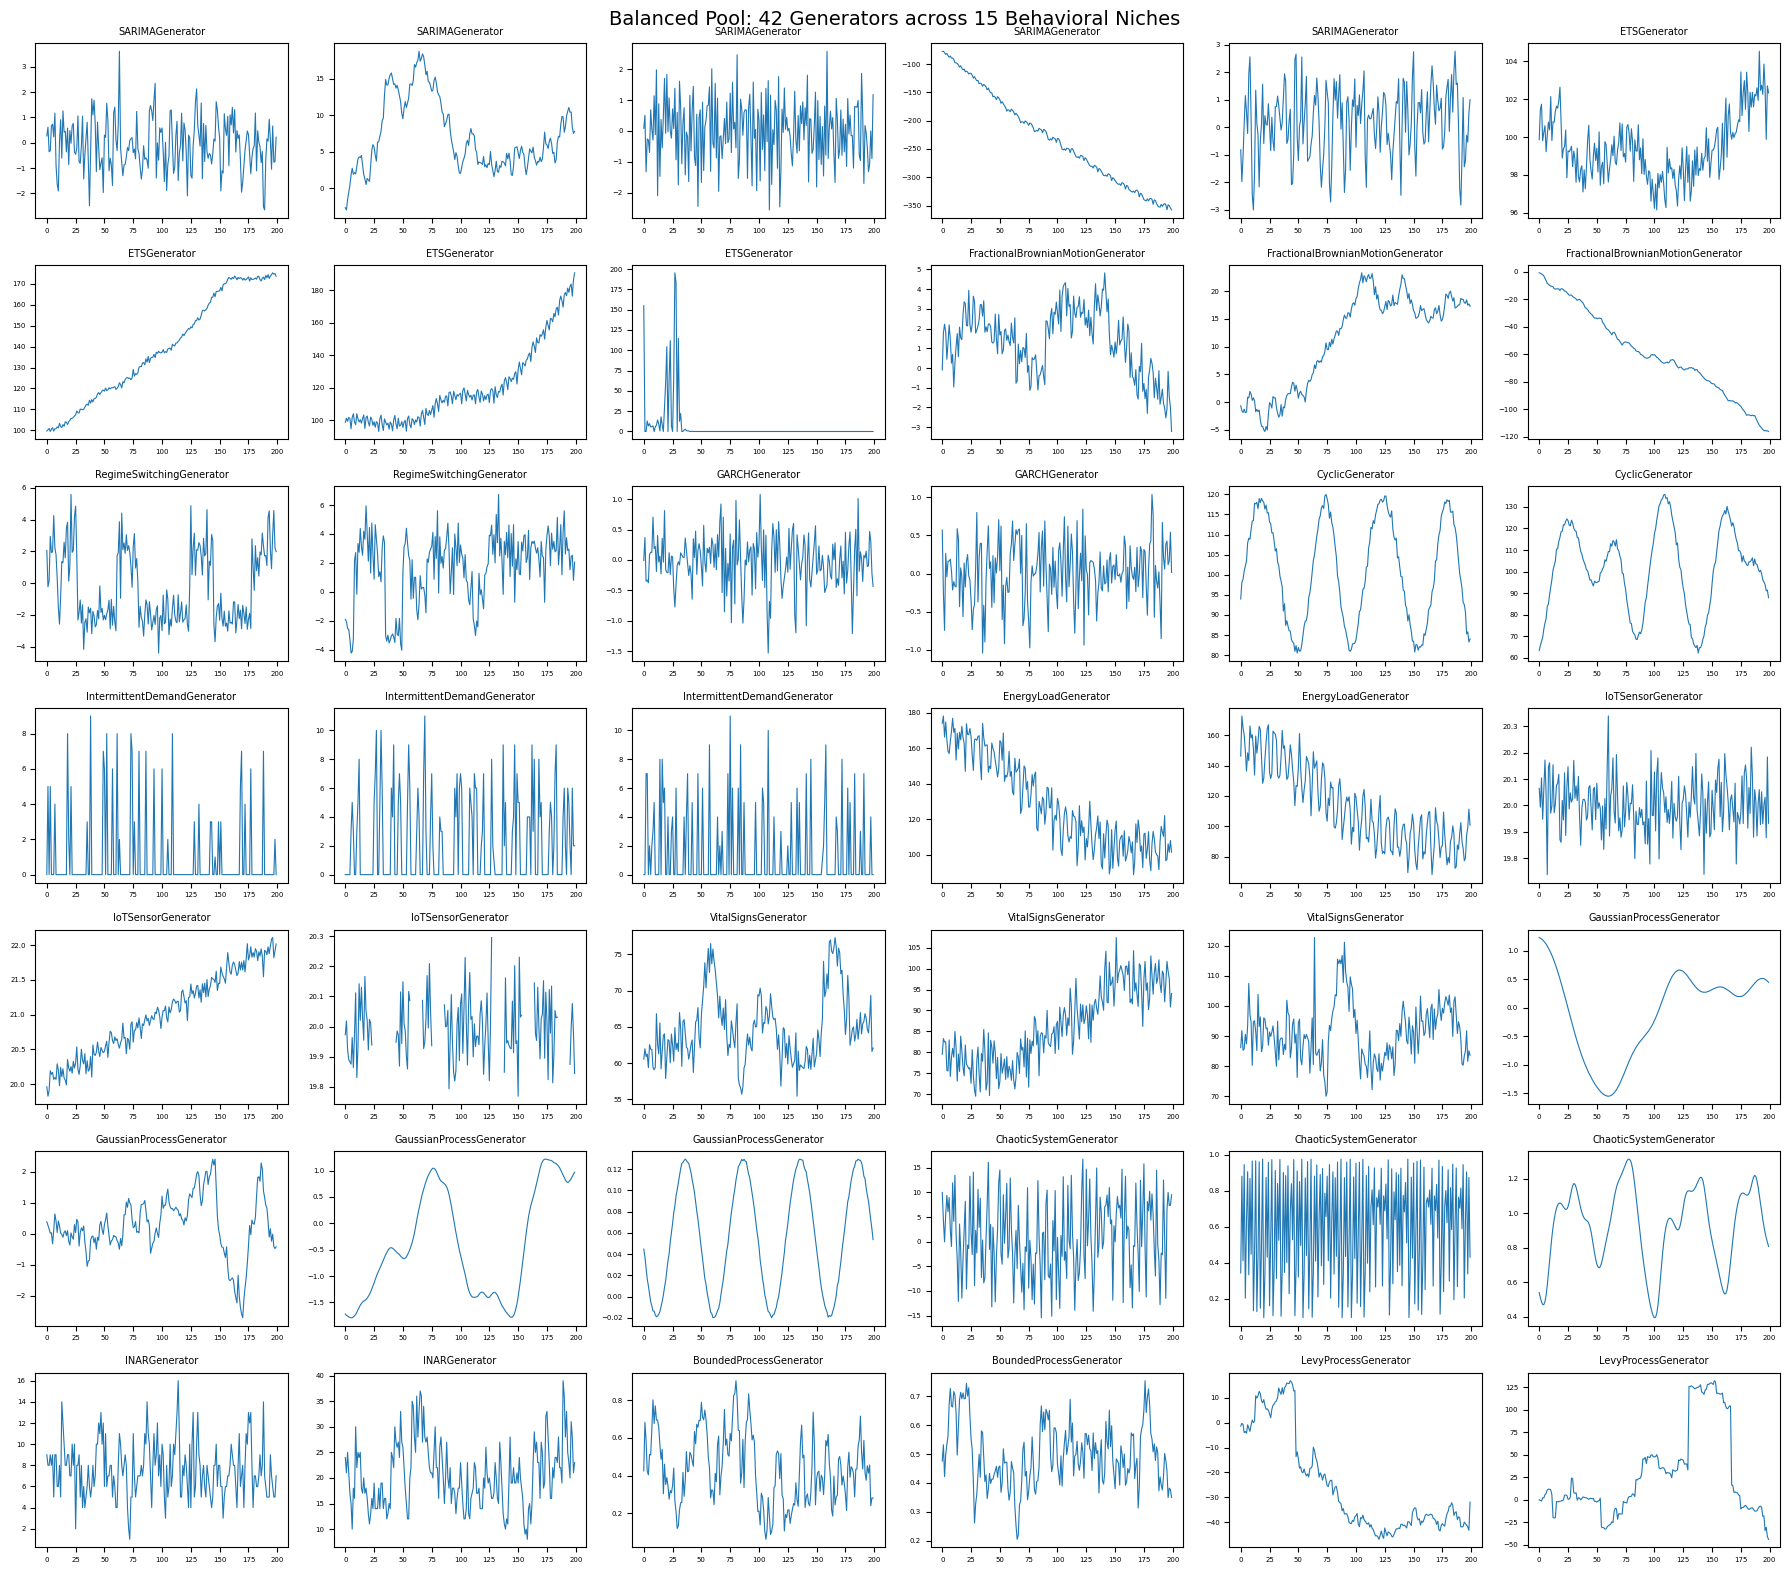

In [ ]:
fig, axes = plt.subplots(7, 6, figsize=(18, 16))
axes = axes.flatten()

for i, gen in enumerate(generators):
    uid = str(i)
    series = df.filter(pl.col("unique_id") == uid)
    values = series["y"].to_list()
    axes[i].plot(values, linewidth=0.8)
    axes[i].set_title(gen.alias, fontsize=7)
    axes[i].tick_params(labelsize=5)

fig.suptitle("Balanced Pool: 42 Generators across 15 Behavioral Niches", fontsize=14)
plt.tight_layout()
plt.show()

## Niche Deep-Dives

Each behavioral niche contributes a different number of generators. Below we group them by niche and plot the variants side by side.

In [ ]:
niches = [
    ("ARMA + Seasonality (SARIMA)", list(range(0, 5))),
    ("Exponential Smoothing (ETS)", list(range(5, 9))),
    ("Long-Range Memory (FBM)", list(range(9, 12))),
    ("Structural Breaks (Regime Switching)", list(range(12, 14))),
    ("Volatility Clustering (GARCH)", list(range(14, 16))),
    ("Irregular Cycles (Cyclic)", list(range(16, 18))),
    ("Sparse/Intermittent (Intermittent Demand)", list(range(18, 21))),
    ("Multi-Seasonal (Energy Load)", list(range(21, 23))),
    ("Sensor Artifacts (IoT Sensor)", list(range(23, 26))),
    ("Physiological (Vital Signs)", list(range(26, 29))),
    ("Smooth/Rough Functions (Gaussian Process)", list(range(29, 33))),
    ("Deterministic Chaos (Chaotic System)", list(range(33, 36))),
    ("Count Time Series (INAR)", list(range(36, 38))),
    ("Bounded/Proportion Data (Bounded Process)", list(range(38, 40))),
    ("Heavy-Tailed Processes (Levy Process)", list(range(40, 42))),
]

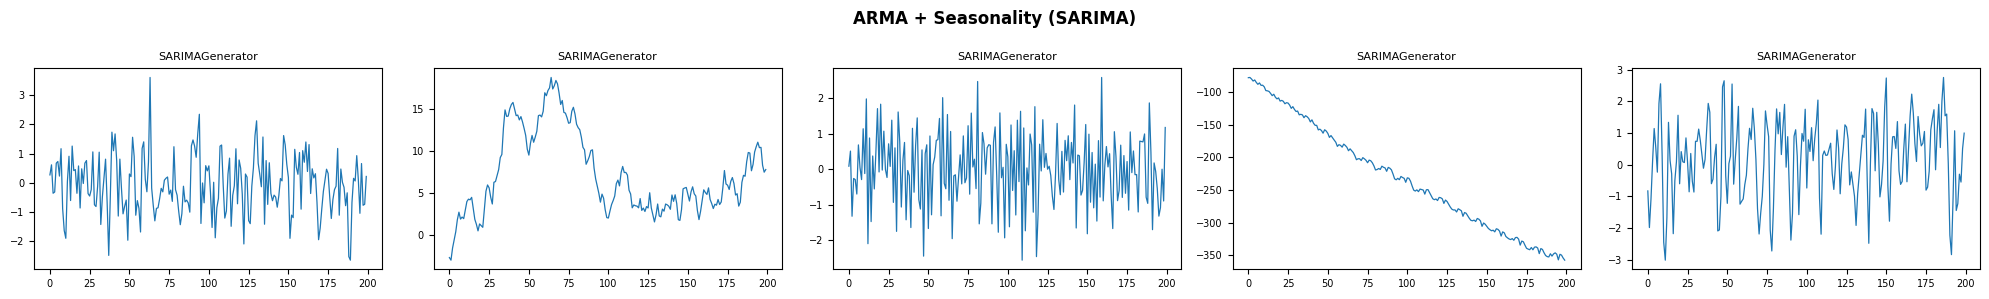

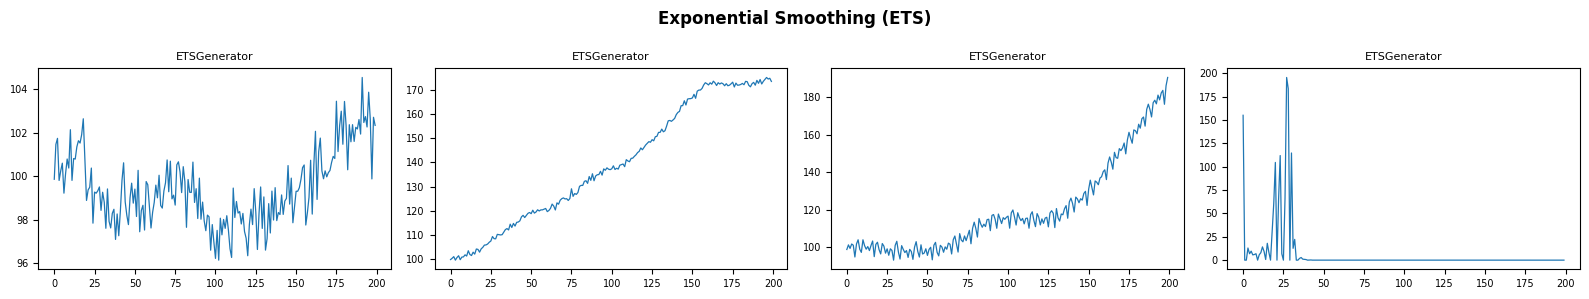

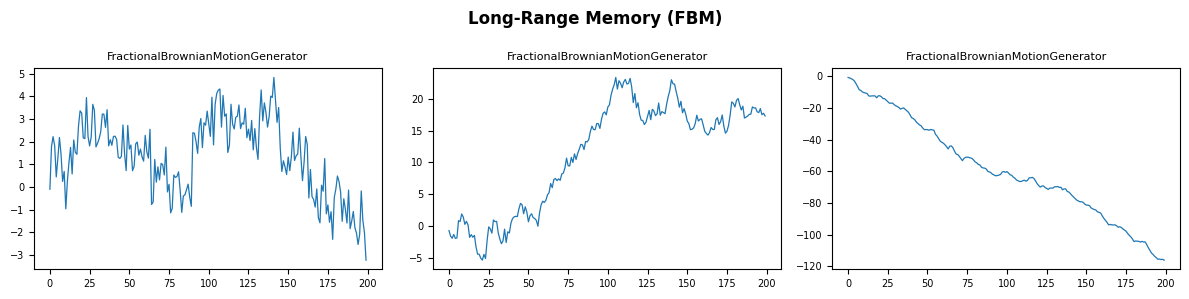

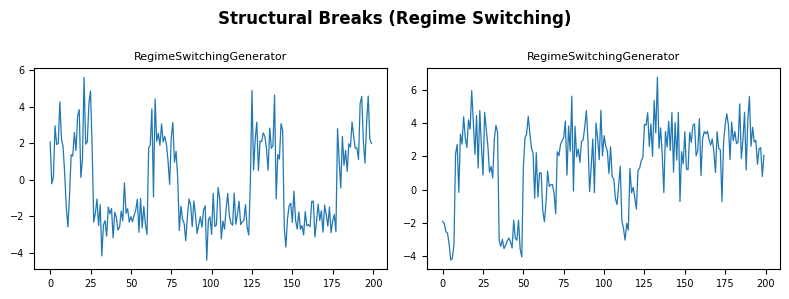

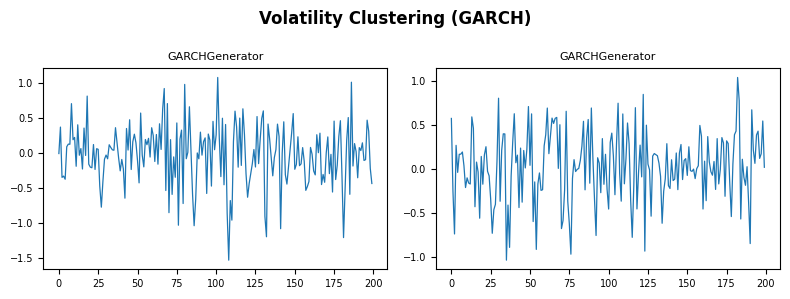

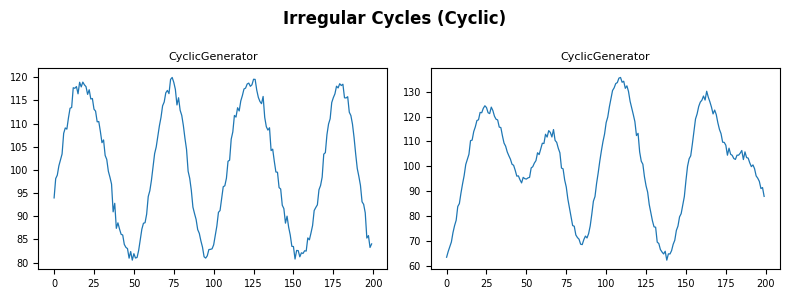

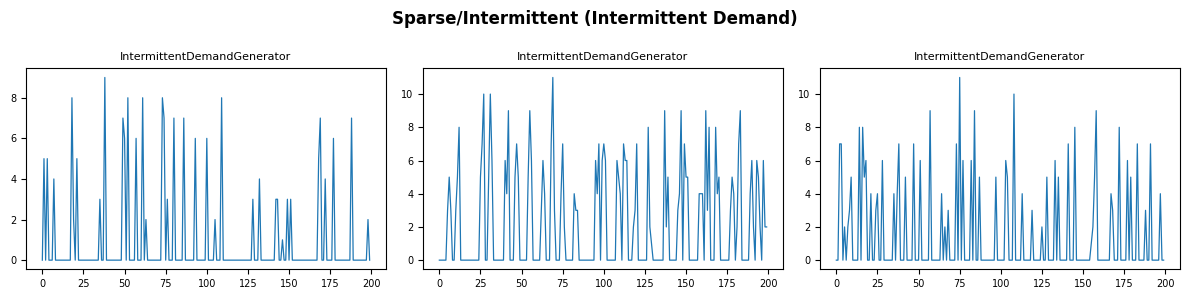

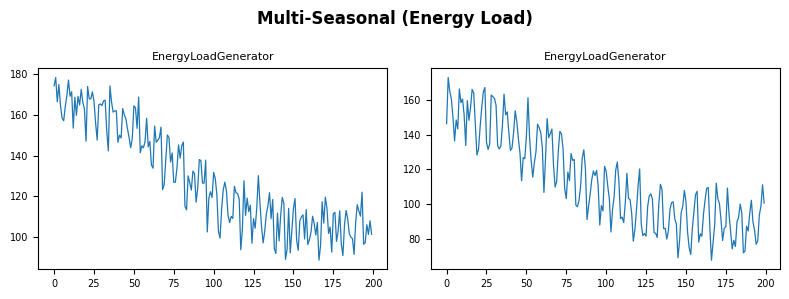

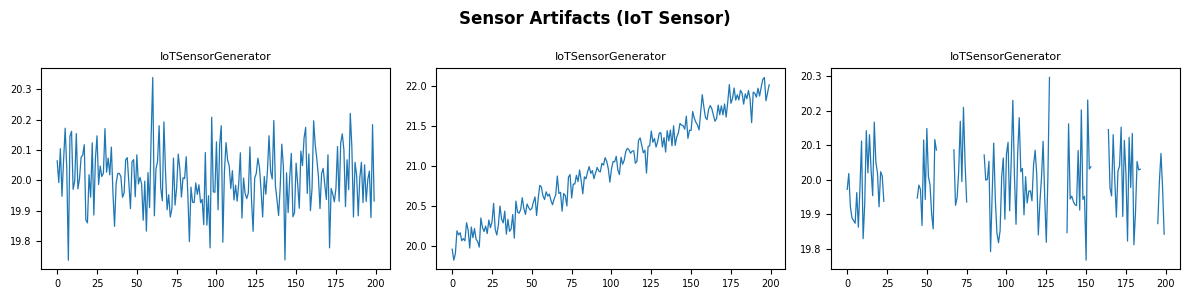

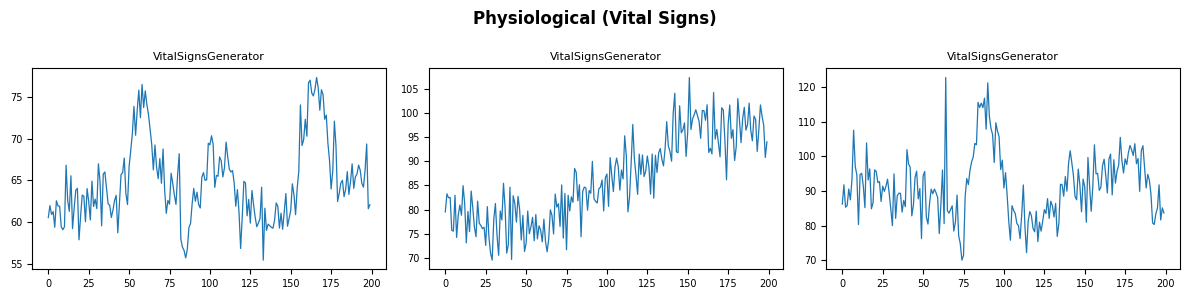

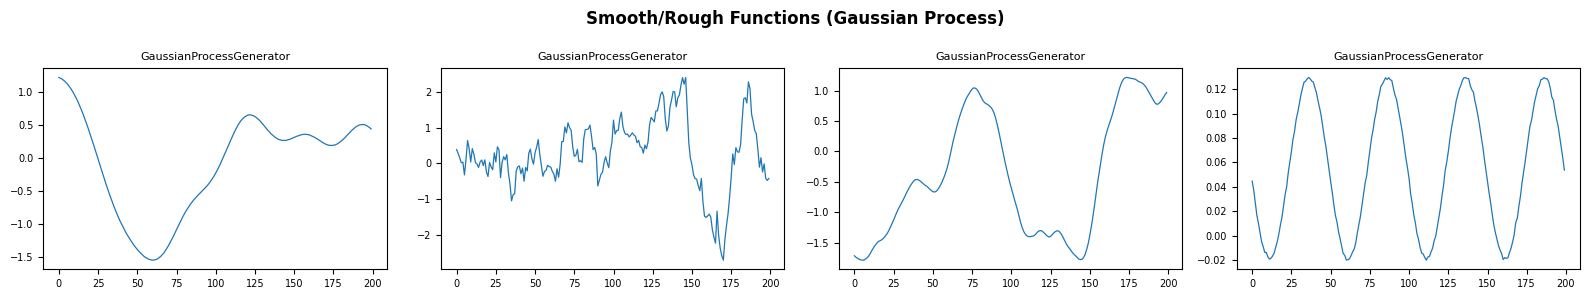

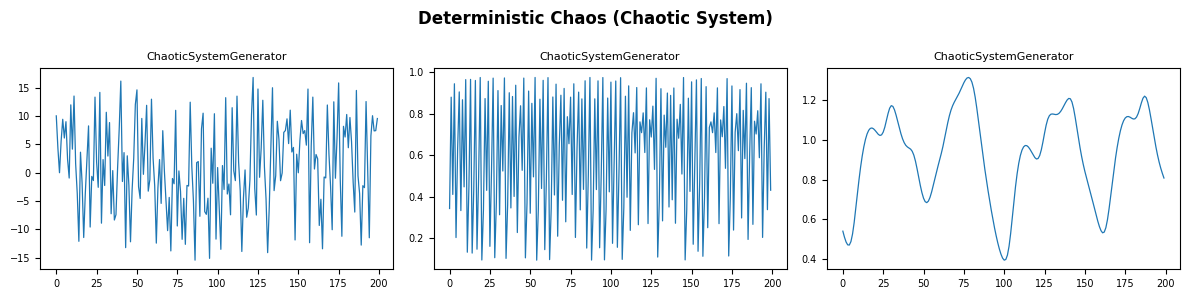

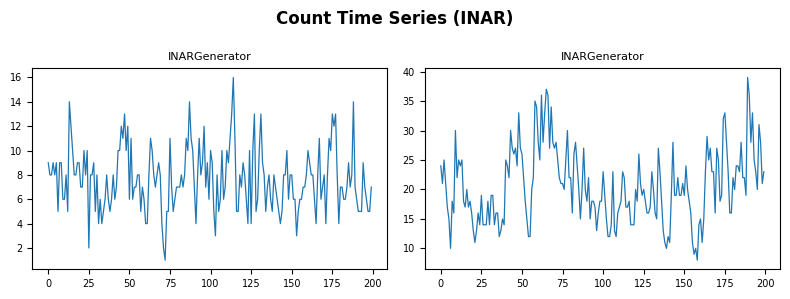

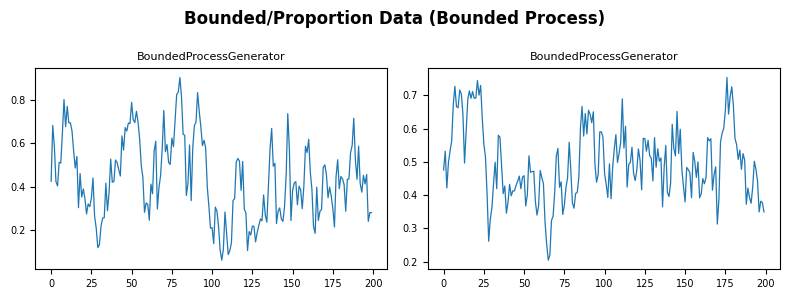

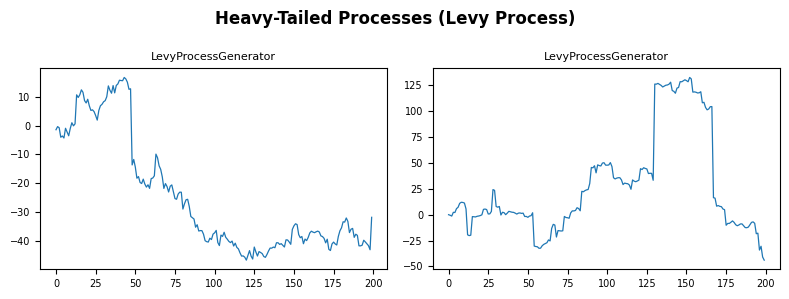

In [ ]:
for niche_name, indices in niches:
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), squeeze=False)
    fig.suptitle(niche_name, fontsize=12, fontweight="bold")

    for j, idx in enumerate(indices):
        uid = str(idx)
        series = df.filter(pl.col("unique_id") == uid)
        axes[0][j].plot(series["y"].to_list(), linewidth=0.9)
        axes[0][j].set_title(generators[idx].alias, fontsize=8)
        axes[0][j].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

## Summary Statistics

Compare key statistics across all 42 series to see how the balanced pool spans different value ranges and variabilities.

In [ ]:
stats = (
    df.group_by("unique_id")
    .agg(
        [
            pl.col("y").count().alias("count"),
            pl.col("y").min().alias("min"),
            pl.col("y").max().alias("max"),
            pl.col("y").mean().alias("mean"),
            pl.col("y").std().alias("std"),
        ]
    )
    .sort("unique_id")
)
stats

unique_id,count,min,max,mean,std
cat,u32,f64,f64,f64,f64
"""0""",200,-2.652759,3.609343,-0.068571,0.99059
"""1""",200,-2.9431,18.770876,7.230695,4.868281
"""10""",200,-5.325623,23.33097,11.306948,8.519994
"""11""",200,-116.121731,-0.744045,-58.861643,31.126446
"""12""",200,-4.409192,5.592096,-0.321962,2.315978
…,…,…,…,…,…
"""5""",200,96.138073,104.540914,99.457374,1.680738
"""6""",200,99.42744,175.293536,139.361576,25.08772
"""7""",200,93.115481,190.627616,120.187782,24.510724


## Scaling Up

Generate multiple series per generator for a larger dataset.

In [ ]:
df_large = dataset.generate(n_series_per_generator=5)
print(f"Series: {df_large['unique_id'].n_unique()}")
print(f"Total observations: {len(df_large)}")

Series: 210
Total observations: 42000


Plot five series from a single generator to see intra-generator variation.

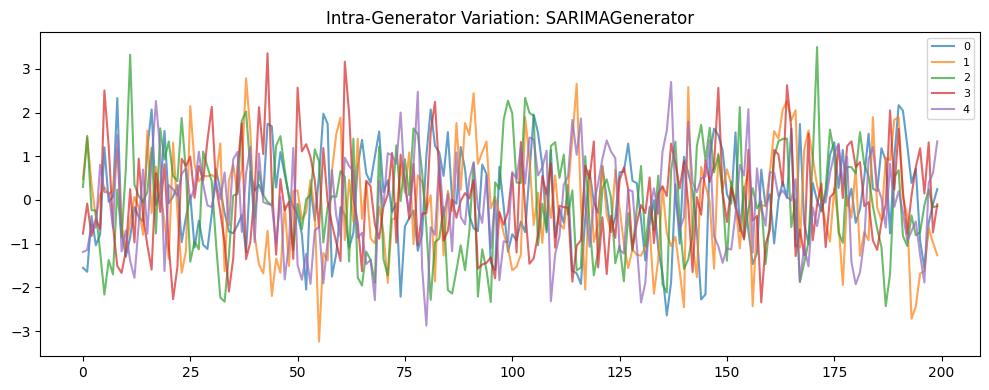

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

# Series 0-4 come from the first generator (Stationary AR(1))
for sid in range(5):
    uid = str(sid)
    series = df_large.filter(pl.col("unique_id") == uid)
    ax.plot(series["y"].to_list(), alpha=0.7, label=uid)

ax.set_title(f"Intra-Generator Variation: {generators[0].alias}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()